# Vertical discretization


Every array has a nominal total vertical extent of **4053.5 m**. Successive layer-thickness increases remain below 50% in all proposed reduced grids.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

## Vertical-grid definitions

In [ ]:
REF84 = np.array([
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.2, 2.4, 2.6, 2.9, 3.1,
    3.4, 3.7, 4.0, 4.4, 4.8, 5.2, 5.7, 6.2, 6.8, 7.4,
    8.1, 8.8, 9.6, 10.5, 11.4, 12.5, 13.6, 14.8, 16.2, 17.6,
    19.2, 21.0, 22.9, 24.9, 27.2, 29.7, 32.4, 35.4, 38.6, 42.1,
    45.9, 50.0, 54.5, 59.4, 64.8, 70.6, 77.0, 84.0, 91.5, 99.7,
    108.7, 118.5, 129.1, 140.8, 153.5, 167.3, 182.4, 198.8, 216.7, 236.2,
    257.5, 280.7, 306.1, 328.5
], dtype=float)

V42 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.895, 7.301, 10.890,
    16.244, 24.230, 36.141, 53.908,
    80.410, 119.940, 178.903, 266.853,
    398.039, 593.717, 885.592, 1320.955
], dtype=float)

V36 = np.array([
    *([4.0] * 12),
    4.400, 4.840, 5.324,
    6.784, 8.645, 11.016, 14.037, 17.887,
    22.792, 29.043, 37.009, 47.159, 60.093,
    76.574, 97.575, 124.336, 158.437, 201.889,
    257.260, 327.816, 417.723, 532.289,
    678.274, 864.298
], dtype=float)

V30 = np.array([
    *([6.0] * 8),
    6.600, 7.260,
    9.214, 11.694, 14.842, 18.838,
    23.908, 30.344, 38.511, 48.878,
    62.035, 78.733, 99.926, 126.823,
    160.961, 204.288, 259.278, 329.069,
    417.646, 530.067, 672.748, 853.837
], dtype=float)

V24 = np.array([
    *([8.0] * 6),
    8.800, 9.680,
    12.947, 17.318, 23.164, 30.982,
    41.441, 55.429, 74.139, 99.164,
    132.637, 177.409, 237.293, 317.391,
    424.526, 567.825, 759.494, 1015.861
], dtype=float)

V18 = np.array([
    *([12.5] * 4),
    13.750,
    19.352, 27.235, 38.330, 53.946,
    75.923, 106.852, 150.383, 211.647,
    297.869, 419.217, 590.001, 830.359,
    1168.636
], dtype=float)


V42_D3000 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.781, 6.965, 10.146,
    14.779, 21.530, 31.363, 45.688,
    66.555, 96.952, 141.234, 205.740,
    299.708, 436.594, 636.001, 926.482
], dtype=float)

V42_D2000 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.628, 6.526, 9.203,
    12.977, 18.299, 25.803, 36.386,
    51.308, 72.351, 102.023, 143.865,
    202.867, 286.067, 403.389, 568.826
], dtype=float)

V42_D1500 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.520, 6.224, 8.572,
    11.805, 16.257, 22.388, 30.832,
    42.460, 58.474, 80.527, 110.897,
    152.722, 210.320, 289.642, 398.878
], dtype=float)

V84_R1_H50 = np.array([
    *([1.0] * 50),
    1.100, 1.324, 1.594, 1.919, 2.310,
    2.780, 3.347, 4.029, 4.850, 5.838,
    7.027, 8.459, 10.183, 12.258, 14.755,
    17.762, 21.381, 25.737, 30.981, 37.294,
    44.893, 54.041, 65.052, 78.307, 94.262,
    113.469, 136.589, 164.421, 197.923, 238.251,
    286.797, 345.234, 415.579, 500.254
], dtype=float)

V42_R4_H48 = np.array([
    *([4.0] * 12),
    4.400, 5.156, 6.042, 7.079, 8.295,
    9.720, 11.390, 13.347, 15.640, 18.326,
    21.474, 25.163, 29.486, 34.551, 40.486,
    47.440, 55.590, 65.139, 76.328, 89.440,
    104.804, 122.808, 143.904, 168.624, 197.590,
    231.532, 271.305, 317.910, 372.520, 436.511
], dtype=float)

V42_R6_H48 = np.array([
    *([6.0] * 8),
    6.600, 7.436, 8.378, 9.439, 10.634,
    11.981, 13.498, 15.207, 17.133, 19.303,
    21.748, 24.502, 27.605, 31.101, 35.040,
    39.478, 44.477, 50.110, 56.456, 63.606,
    71.661, 80.737, 90.962, 102.482, 115.461,
    130.083, 146.557, 165.118, 186.030, 209.589,
    236.133, 266.038, 299.730, 337.687
], dtype=float)

V30_R4_H48_d3000 = np.array([
    4.000, 4.000, 4.000, 4.000,
    4.000, 4.000, 4.000, 4.000,
    4.000, 4.000, 4.000, 4.000,
    4.400, 5.966, 8.088, 10.967,
    14.869, 20.160, 27.334, 37.060,
    50.247, 68.127, 92.369, 125.237,
    169.800, 230.221, 312.143, 423.214,
    573.809, 777.989,
], dtype=float)


V30_R6_H24_d3000  = np.array([
    6.000, 6.000, 6.000, 6.000,
    6.600, 7.830, 9.289, 11.020,
    13.074, 15.510, 18.400, 21.829,
    25.897, 30.723, 36.449, 43.241,
    51.299, 60.859, 72.200, 85.655,
    101.617, 120.554, 143.020, 169.672,
    201.291, 238.802, 283.303, 336.098,
    398.731, 473.037,
], dtype=float)


V30_R6_H48_d3000  = np.array([
    6.000, 6.000, 6.000, 6.000,
    6.000, 6.000, 6.000, 6.000,
    6.600, 8.161, 10.092, 12.479,
    15.430, 19.080, 23.593, 29.174,
    36.075, 44.608, 55.159, 68.206,
    84.339, 104.289, 128.957, 159.460,
    197.178, 243.818, 301.490, 372.803,
    460.985, 570.024,
], dtype=float)


V30_R6_H72_d3000  = np.array([
    6.000, 6.000, 6.000, 6.000,
    6.000, 6.000, 6.000, 6.000,
    6.000, 6.000, 6.000, 6.000,
    6.600, 8.690, 11.442, 15.066,
    19.838, 26.120, 34.392, 45.284,
    59.626, 78.509, 103.373, 136.111,
    179.217, 235.975, 310.708, 409.108,
    538.672, 709.269,
], dtype=float)


V30_R6_H96_d3000  = np.array([
    6.000, 6.000, 6.000, 6.000,
    6.000, 6.000, 6.000, 6.000,
    6.000, 6.000, 6.000, 6.000,
    6.000, 6.000, 6.000, 6.000,
    6.600, 9.651, 14.113, 20.637,
    30.178, 44.129, 64.530, 94.362,
    137.985, 201.776, 295.056, 431.460,
    630.924, 922.599,
], dtype=float)


V30_R8_H48_d3000  = np.array([
    8.000, 8.000, 8.000,
    8.000, 8.000, 8.000,
    8.800, 10.469, 12.455, 14.818,
    17.629, 20.973, 24.952, 29.685,
    35.316, 42.015, 49.985, 59.467,
    70.748, 84.169, 100.135, 119.130,
    141.729, 168.614, 200.600, 238.653,
    283.924, 337.783, 401.859, 478.092,
], dtype=float)


V30_R10_H50_d3000  = np.array([
    10.000, 10.000, 10.000, 10.000, 10.000,
    11.000, 12.811, 14.920, 17.376,
    20.237, 23.568, 27.448, 31.967,
    37.229, 43.358, 50.496, 58.808,
    68.490, 79.765, 92.896, 108.189,
    126.000, 146.743, 170.900, 199.034,
    231.801, 269.961, 314.403, 366.161,
    426.439,
], dtype=float)


V30_R12p5_H50_d3000 = np.array([
    12.500, 12.500, 12.500, 12.500,
    13.750, 15.700, 17.926, 20.467,
    23.369, 26.682, 30.466, 34.785,
    39.717, 45.349, 51.778, 59.120,
    67.502, 77.073, 88.001, 100.478,
    114.724, 130.991, 149.563, 170.769,
    194.982, 222.627, 254.193, 290.234,
    331.385, 378.369,
], dtype=float)



GRIDS = {
    "REF84": REF84,
    "V42": V42,
    "V42-3000 meter": V42_D3000,
    "V42-2000 meter": V42_D2000,
    "V42-1500 meter": V42_D1500,
    "V84-R1-3000 meter": V84_R1_H50,
    "V42-R4-3000 meter": V42_R4_H48,
    "V42-R6-3000 meter": V42_R6_H48,
}

In [3]:
REFERENCE_NR = len(REF84)
TARGET_DEPTH = REF84.sum()

print(f"{'Grid':<10} {'Nr':>4} {'Depth [m]':>12} {'Reduction':>12} {'Max increase':>14}")
print("-" * 58)

for name, delR in GRIDS.items():
    growth = delR[1:] / delR[:-1] - 1.0
    reduction = 1.0 - len(delR) / REFERENCE_NR

    print(
        f"{name:<10} "
        f"{len(delR):>4d} "
        f"{delR.sum():>12.1f} "
        f"{100*reduction:>11.1f}% "
        f"{100*np.max(growth):>13.1f}%"
    )


Grid         Nr    Depth [m]    Reduction   Max increase
----------------------------------------------------------
REF84        84       4053.5         0.0%          11.5%
V42          42       4053.5        50.0%          49.2%
V42-3000 meter   42       3000.0        50.0%          49.2%
V42-2000 meter   42       2000.0        50.0%          49.2%
V42-1500 meter   42       1500.0        50.0%          49.2%
V84-R1-3000 meter   84       3000.0         0.0%          20.4%
V42-R4-3000 meter   42       3000.0        50.0%          17.2%
V42-R6-3000 meter   42       3000.0        50.0%          12.7%


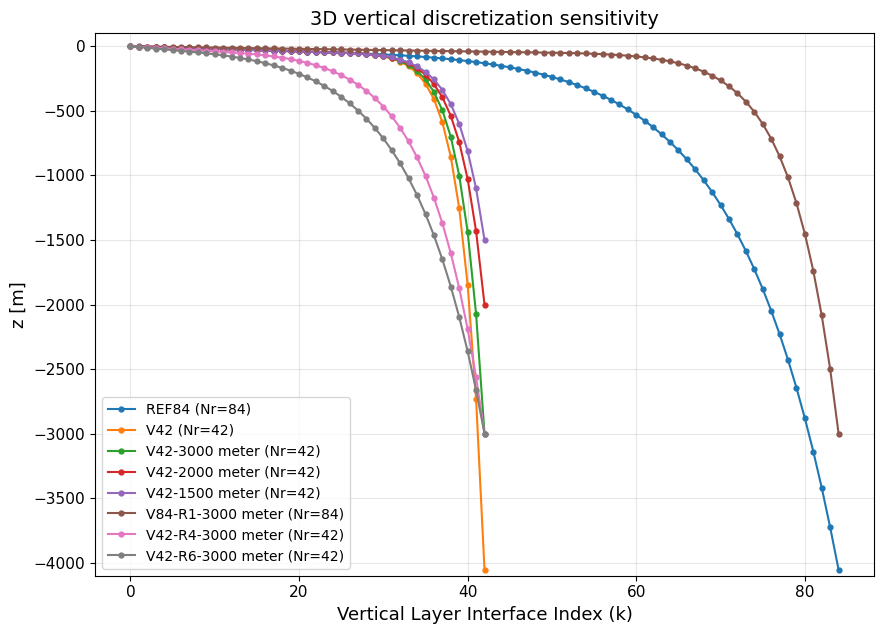

In [4]:
def cell_interface_depths(delR):
    delR = np.asarray(delR, dtype=float)
    return np.concatenate([[0.0], -np.cumsum(delR)])


fig, ax = plt.subplots(figsize=(9.0, 6.5))

for name, delR in GRIDS.items():
    z = cell_interface_depths(delR)
    # Interface indices run from 0 (surface) to len(delR) (bottom)
    k = np.arange(len(z))
    ax.plot(
        k,
        z,
        marker="o",
        markersize=3.5,
        linewidth=1.5,
        label=f"{name} (Nr={len(delR)})",
    )

ax.set_title("3D vertical discretization sensitivity")
ax.set_xlabel("Vertical Layer Interface Index (k)")
ax.set_ylabel("z [m]")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", frameon=True)
ax.set_ylim(-4100, 100)

fig.tight_layout()
plt.show()

## Upper-ocean zoom

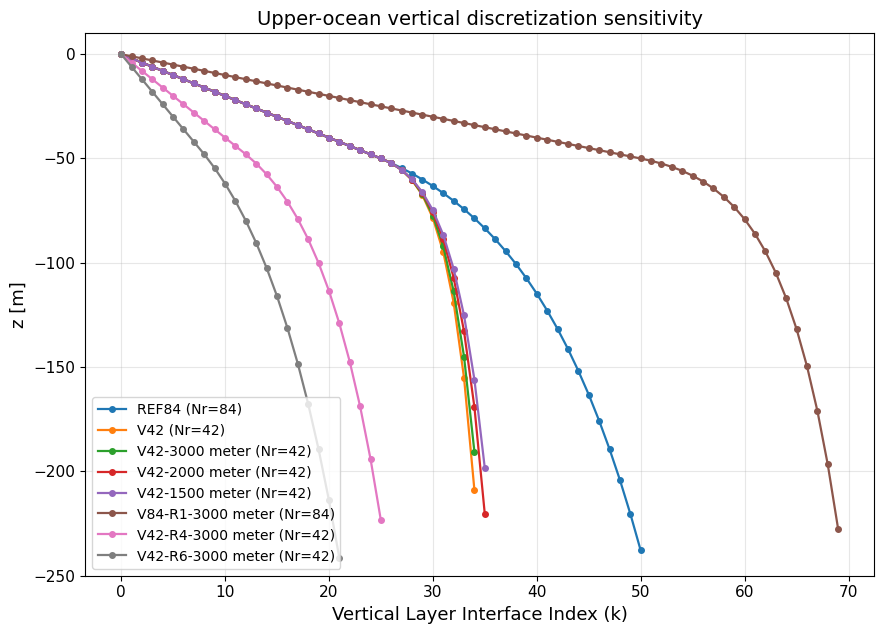

In [5]:
fig, ax = plt.subplots(figsize=(9.0, 6.5))

for name, delR in GRIDS.items():
    z = cell_interface_depths(delR)
    k = np.arange(len(z))  # Match length of interface array (Nr + 1)
    mask = z >= -250.0
    ax.plot(
        k[mask],
        z[mask],
        marker="o",
        markersize=4.0,
        linewidth=1.6,
        label=f"{name} (Nr={len(delR)})",
    )

ax.set_title("Upper-ocean vertical discretization sensitivity")
ax.set_xlabel("Vertical Layer Interface Index (k)")
ax.set_ylabel("z [m]")
ax.set_ylim(-250, 10)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", frameon=True)

fig.tight_layout()
plt.show()